In [ ]:
import torch
import time
from PIL import Image
from transformers import  AutoProcessor
from transformers import AutoModelForImageTextToText
from datasets import load_dataset
import pandas as pd
#from transformers import AutoProcessor, AutoModelForVision2Seq

In [ ]:


# ── Config ──────────────────────────────────────────────
MODEL_ID   = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"
NUM_SAMPLES = 10   # how many examples to evaluate


if torch.cuda.is_available():
    current_id = torch.cuda.current_device()
    print(f"Current Device ID: {current_id}")
    print(f"Device Name: {torch.cuda.get_device_name(current_id)}")
else:
    print("No GPU available; running on CPU.")

Current Device ID: 0
Device Name: NVIDIA GeForce RTX 5080


In [26]:

SYSTEM_PROMPT = """You are an expert Gastrointestinal (GI) tract endoscopy AI assistant.
Analyze colonoscopy and endoscopy images carefully and answer questions concisely.Question Types: Yes/No, single-choice, multiple-choice, color-related, location-related, numerical count.The dataset includes images from various GI tract conditions and medical instruments used in GI procedures
⚠ For educational/research use only."""

In [27]:

# ── Load Model ────────────────────────────────────────────
print("Loading SmolVLM2-2.2B...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
  
    device_map="auto",
)
print("✅ SmolVLM2-2.2B loaded!")

Loading SmolVLM2-2.2B...


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

✅ SmolVLM2-2.2B loaded!


In [10]:
# ── Load Kvasir-VQA Dataset ───────────────────────────────
print("Loading Kvasir-VQA dataset...")
ds = load_dataset("SimulaMet-HOST/Kvasir-VQA")
dataset = ds["raw"]
print(f"✅ Dataset loaded! Total rows: {len(dataset)}\n")

Loading Kvasir-VQA dataset...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

data/00000.parquet:   0%|          | 0.00/26.8M [00:00<?, ?B/s]

...

data/00029.parquet:   0%|          | 0.00/60.7M [00:00<?, ?B/s]

data/00030.parquet:   0%|          | 0.00/67.0M [00:00<?, ?B/s]

Generating raw split:   0%|          | 0/58849 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

✅ Dataset loaded! Total rows: 58849



In [28]:
d_path ="data" #existing folder where you want to save images and metadata.csv

df = ds['raw'].select_columns(['source', 'question', 'answer', 'img_id']).to_pandas()
df.to_csv(f"{d_path}/metadata.csv", index=False)

import os
os.makedirs(f"{d_path}/images", exist_ok=True)

for i, row in df.groupby('img_id').nth(0).iterrows(): # for images
  image = ds['raw'][i]['image'].save(f"{d_path}/images/{row['img_id']}.jpg")

In [11]:
# ── Preview dataset structure ─────────────────────────────
print("── Dataset columns:", dataset.column_names)
print("── Sample categories:", dataset.unique("source"))
print("── Sample questions:",  dataset.unique("question")[:5], "\n")

── Dataset columns: ['image', 'source', 'question', 'answer', 'img_id']
── Sample categories: ['Ulcerative Colitis', 'Polyps', 'Esophagitis', 'Normal', 'Instrument']
── Sample questions: ['Are there any abnormalities in the image? Check all that are present.', 'Are there any anatomical landmarks in the image? Check all that are present.', 'Are there any instruments in the image? Check all that are present.', 'Have all polyps been removed?', 'Is this finding easy to detect?'] 



In [16]:
import base64
from io import BytesIO
from IPython.display import display, HTML
# ── Helper: PIL image → base64 for HTML display ───────────
def image_to_base64(pil_image):
    buffer = BytesIO()
    pil_image.save(buffer, format="JPEG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

# ── Helper: display one result as a styled HTML card ──────
def show_result_card(i, image, source, question, gt_answer, predicted, correct, elapsed):
    img_b64 = image_to_base64(image)
    border  = "#2ecc71" if correct else "#e74c3c"   # green if correct, red if wrong
    icon    = "✅" if correct else "❌"

    html = f"""
    <div style="
        display: flex;
        gap: 20px;
        border: 2px solid {border};
        border-radius: 12px;
        padding: 16px;
        margin: 12px 0;
        background: #1a1a2e;
        font-family: 'Segoe UI', sans-serif;
        color: #eee;
    ">
        <!-- Left: Image -->
        <div style="flex-shrink: 0;">
            <img src="data:image/jpeg;base64,{img_b64}"
                 style="width:200px; height:200px; object-fit:cover;
                        border-radius:8px; border:1px solid #444;"/>
            <div style="text-align:center; margin-top:6px;
                        font-size:11px; color:#aaa;">
                🔬 {source}
            </div>
        </div>

        <!-- Right: Details -->
        <div style="flex: 1;">
            <div style="font-size:13px; color:#888; margin-bottom:8px;">
                Sample #{i+1}
            </div>

            <div style="margin-bottom:10px;">
                <span style="color:#74b9ff; font-weight:bold;">❓ Question</span><br/>
                <span style="font-size:15px;">{question}</span>
            </div>

            <div style="margin-bottom:10px;">
                <span style="color:#55efc4; font-weight:bold;">✔ Ground Truth</span><br/>
                <span style="font-size:15px;">{gt_answer}</span>
            </div>

            <div style="margin-bottom:10px;">
                <span style="color:#fdcb6e; font-weight:bold;">🤖 Predicted</span><br/>
                <span style="font-size:15px;">{predicted}</span>
            </div>

            <div style="display:flex; gap:20px; margin-top:12px;
                        font-size:13px; color:#aaa;">
                <span>{icon} <b style="color:{border};">
                    {"Correct" if correct else "Incorrect"}
                </b></span>
                <span>⏱ {elapsed:.2f}s</span>
            </div>
        </div>
    </div>
    """
    display(HTML(html))

In [23]:
# ── Inference Function ────────────────────────────────────
def run_vlm(image, question: str) -> str:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": f"{SYSTEM_PROMPT}\n\nQuestion: {question}\nAnswer concisely:"}
            ]
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device, dtype=torch.bfloat16)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=128,   # short answers for VQA
            do_sample=False,
        )

    # Decode only new tokens
    new_tokens = output_ids[:, inputs["input_ids"].shape[-1]:]
    return processor.batch_decode(new_tokens, skip_special_tokens=True)[0].strip()


In [30]:
# Map semantically equivalent answers to a canonical form
ANSWER_SYNONYMS = {
    "none":     ["no", "none", "not present", "absent", "nothing", "0", "zero", "there are none", "no instruments"],
    "yes":      ["yes", "correct", "true", "present", "there is", "i can see"],
    "no":       ["no", "false", "not", "none", "absent", "cannot see"],
    "normal":   ["normal", "no abnormality", "no findings", "unremarkable"],
    "colonoscopy": ["colonoscopy", "colon", "colonoscopic"],
}

def normalize_answer(text: str) -> str:
    """Map synonyms to a single canonical answer."""
    text = text.lower().strip()
    for canonical, synonyms in ANSWER_SYNONYMS.items():
        if any(syn in text for syn in synonyms):
            return canonical
    return text  # return as-is if no match found



In [31]:
# ── Batch Evaluation ──────────────────────────────────────
print(f"Running inference on {NUM_SAMPLES} samples...\n")
results = []

for i, sample in enumerate(dataset.select(range(NUM_SAMPLES))):
    image     = sample["image"].convert("RGB")
    question  = sample["question"]
    gt_answer = sample["answer"]
    source    = sample["source"]
    img_id    = sample["img_id"]

    t0 = time.time()
    predicted = run_vlm(image, question)

    # ✅ Normalized matching instead of raw string check
    gt_norm   = normalize_answer(gt_answer)
    pred_norm = normalize_answer(predicted)
    correct   = (gt_norm == pred_norm) or (gt_norm in predicted.lower())

    print(f"[{i+1}/{NUM_SAMPLES}] {source}")
    print(f"Q:         {question}")
    print(f"GT Answer: {gt_answer}  →  normalized: {gt_norm}")
    print(f"Predicted: {predicted}  →  normalized: {pred_norm}")
    print(f"✅ Correct: {correct} | ⏱ {elapsed:.1f}s\n")
    elapsed   = time.time() - t0

    
    results.append({
        "img_id":    img_id,
        "source":    source,
        "question":  question,
        "gt_answer": gt_answer,
        "predicted": predicted,
        "correct":   correct,
        "time_s":    round(elapsed, 2),
    })

   

Running inference on 10 samples...

[1/10] Ulcerative Colitis
Q:         Are there any abnormalities in the image? Check all that are present.
GT Answer: ulcerative colitis  →  normalized: ulcerative colitis
Predicted: No abnormalities  →  normalized: none
✅ Correct: False | ⏱ 0.4s

[2/10] Ulcerative Colitis
Q:         Are there any anatomical landmarks in the image? Check all that are present.
GT Answer: none  →  normalized: none
Predicted: Yes, there are anatomical landmarks in the image  →  normalized: yes
✅ Correct: False | ⏱ 0.5s

[3/10] Ulcerative Colitis
Q:         Are there any instruments in the image? Check all that are present.
GT Answer: none  →  normalized: none
Predicted: No  →  normalized: none
✅ Correct: True | ⏱ 0.5s

[4/10] Ulcerative Colitis
Q:         Have all polyps been removed?
GT Answer: not relevant  →  normalized: none
Predicted: No  →  normalized: none
✅ Correct: True | ⏱ 0.4s

[5/10] Ulcerative Colitis
Q:         Is this finding easy to detect?
GT Answer: ye

In [33]:
# ── Final Summary Banner ──────────────────────────────────
df       = pd.DataFrame(results)
accuracy = df["correct"].mean() * 100
avg_time = df["time_s"].mean()

print(f'accuracy: {accuracy:.2f}% | avg inference time: {avg_time:.2f}s per sample')

accuracy: 50.00% | avg inference time: 0.38s per sample


In [17]:
# ── Main Evaluation Loop ──────────────────────────────────
results = []

for i, sample in enumerate(dataset.select(range(NUM_SAMPLES))):
    image     = sample["image"].convert("RGB")
    question  = sample["question"]
    gt_answer = sample["answer"]
    source    = sample["source"]
    img_id    = sample["img_id"]

    # Build message for the model
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": f"{SYSTEM_PROMPT}\n\nQuestion: {question}\nAnswer concisely:"}
        ]
    }]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device, dtype=torch.bfloat16)

    t0 = time.time()
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    elapsed = time.time() - t0

    new_tokens = output_ids[:, inputs["input_ids"].shape[-1]:]
    predicted  = processor.batch_decode(new_tokens, skip_special_tokens=True)[0].strip()
    correct    = gt_answer.lower().strip() in predicted.lower().strip()



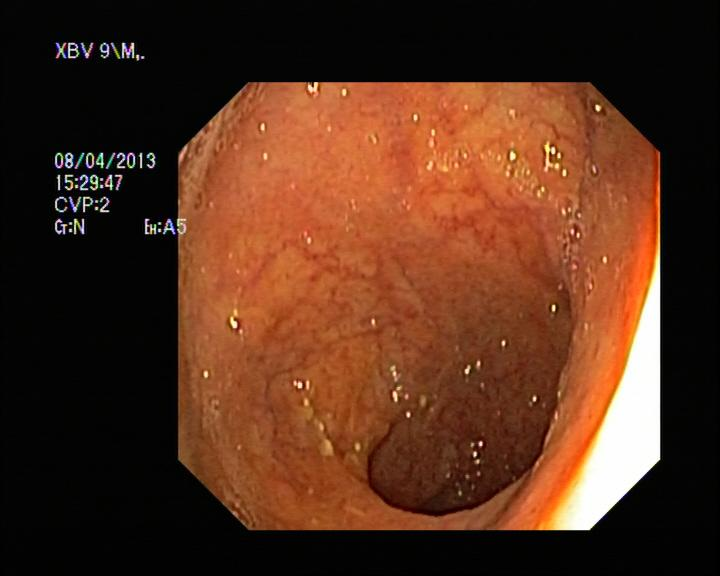

📄 Results saved to kvasir_vqa_results.csv


In [19]:
# 🖼️ Display card with image
show_result_card(i, image, source, question, gt_answer, predicted, correct, elapsed)

results.append({
        "img_id":    img_id,
        "source":    source,
        "question":  question,
        "gt_answer": gt_answer,
        "predicted": predicted,
        "correct":   correct,
        "time_s":    round(elapsed, 2),
    })

# ── Final Summary Banner ──────────────────────────────────
df       = pd.DataFrame(results)
accuracy = df["correct"].mean() * 100
avg_time = df["time_s"].mean()

display(HTML(f"""
<div style="
    border: 2px solid #a29bfe;
    border-radius: 12px;
    padding: 20px;
    margin-top: 20px;
    background: #1a1a2e;
    font-family: 'Segoe UI', sans-serif;
    color: #eee;
    text-align: center;
">
    <div style="font-size:22px; font-weight:bold; color:#a29bfe;">
        📊 Evaluation Summary
    </div>
    <div style="font-size:36px; font-weight:bold; margin:12px 0; color:#55efc4;">
        {accuracy:.1f}% Accuracy
    </div>
    <div style="color:#aaa; font-size:14px;">
        {int(df['correct'].sum())} correct out of {NUM_SAMPLES} samples
        &nbsp;|&nbsp; ⏱ Avg {avg_time:.2f}s per sample
    </div>
</div>
"""))

df.to_csv("kvasir_vqa_results.csv", index=False)
print("📄 Results saved to kvasir_vqa_results.csv")
                                    

In [20]:
# ── Results Summary ───────────────────────────────────────
df = pd.DataFrame(results)
accuracy = df["correct"].mean() * 100
avg_time = df["time_s"].mean()

print("═" * 50)
print(f"  Accuracy : {accuracy:.1f}%  ({df['correct'].sum()}/{NUM_SAMPLES})")
print(f"  Avg Time : {avg_time:.2f}s per sample")
print("═" * 50)

# Save results to CSV
df.to_csv("kvasir_vqa_results.csv", index=False)
print("\n📄 Results saved to kvasir_vqa_results.csv")

══════════════════════════════════════════════════
  Accuracy : 0.0%  (0/10)
  Avg Time : 0.27s per sample
══════════════════════════════════════════════════

📄 Results saved to kvasir_vqa_results.csv
